In [3]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langchain_community.tools import DuckDuckGoSearchRun
from dotenv import load_dotenv

load_dotenv()

C:\Users\dell\AppData\Local\Temp\ipykernel_23140\407901463.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


True

In [4]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')
embedding = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')    

In [5]:
# 1. just load the doc

docs = (
    TextLoader("../Document/hr.txt").load()
)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(docs)

vector_store = FAISS.from_documents(chunks, embedding=embedding)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [ ]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------

class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str

    web_query: str
    total_web_search:int

    ans_is_supported: Literal["fully_supported", "partially_supported", "no_support"]

    answer: str

In [18]:
# --------------------------------------------------
# find that retrival is needed or not
# --------------------------------------------------

class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


def decide_retrieval(state: State):
    question = state['question']

    res = (decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision) ).invoke({'question': question}).should_retrieve
    
    return {
        'need_retrieval': res
    }

In [19]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "I don't know based on my general knowledge.\n"
            "if question say that use the use the context or use knowledgebase then you do not give the answer by your self"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content[0]['text']
    }

In [20]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [21]:
# --------------------------------------------------
# check that retrival doc is relevant or not to generate the answer
# --------------------------------------------------

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)


def is_relevant(state:State):

    relevant_docs : List[Document] = []
    
    chain = (is_relevant_prompt | llm.with_structured_output(RelevanceDecision))
    
    for d in state['docs']:
        res = chain.invoke({'question':state['question'], 'document':d}).is_relevant

        if res :
            relevant_docs.append(d)

    return {
        'relevant_docs':relevant_docs
    }

In [22]:
def route_after_decide(state:State):

    if state['need_retrieval']:
        return "retrieve"
    else:
        return "generate_direct"

In [34]:
# --------------------
# if one of the retrieval doc is relavent then generate the answer 
# --------------------

rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state:State):

    context = "".join([d.page_content for d in state['relevant_docs']]).strip()

    out = (rag_generation_prompt | llm ).invoke({'question': state['question'], "context":context})

    return {
        'answer': out.content[0]['text'], 
        'context':context
    }

In [35]:
# -----------------------------
# web search & query rewrite
# -----------------------------
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state:State)->str:
    query = state["question"]

    rewrite_query = rewrite_chain.invoke({"question":query}).query

    return {
        'web_query':rewrite_query
    }

def web_search(state:State):
    search = DuckDuckGoSearchRun()

    q = state["web_query"]
    total_web_search = state['total_web_search']
    # Run a query directly
    results = search.run(q)

    return {
        "docs":[Document(page_content=results)],
        "total_web_search": total_web_search - 1
    }

In [36]:
def route_after_relevance(state:State):
    if len(state['relevant_docs']) > 0 or state['total_web_search'] == 0:
        return "generate_from_context"
    else :
        return "rewrite_query_node"

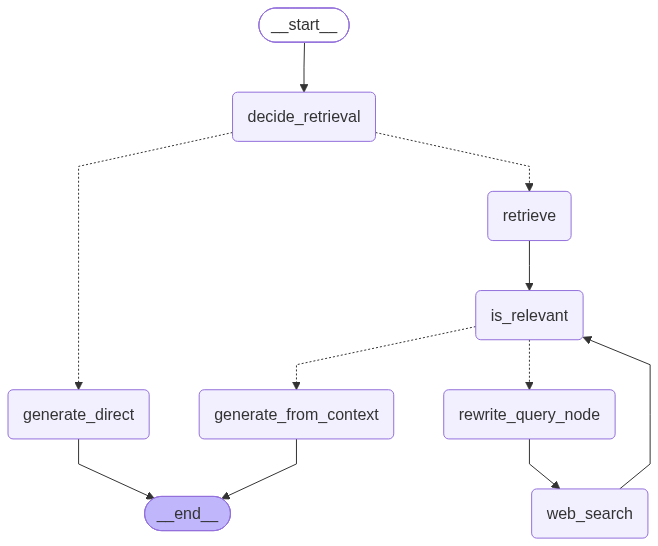

In [37]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant) 
g.add_node("generate_from_context", generate_from_context)
g.add_node("rewrite_query_node", rewrite_query_node)
g.add_node("web_search", web_search)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant") 

g.add_conditional_edges("is_relevant", route_after_relevance, {
    "generate_from_context":"generate_from_context",
    "rewrite_query_node":"rewrite_query_node"
}) # New

g.add_edge("rewrite_query_node", "web_search")

g.add_edge("web_search", "is_relevant")

app = g.compile()
app

In [38]:
result = app.invoke(
    {
        "question": "what is cto from the DOC",
        "need_retrieval": False,
        "docs": [],
        "web_query":"",
        "answer": "",
        'total_web_search':1
    }
)


In [39]:
result

{'question': 'what is cto from the DOC',
 'need_retrieval': True,
 'docs': [Document(metadata={}, page_content="Department of Commerce Acting Chief Technology Officer Matt Passos said the agency is deploying agentic artificial intelligence (AI) to support workforce productivity, enterprise coordination, and mission delivery, while emphasizing security and governance as central to adoption. The Commerce Department is encouraging employees across the agency to develop their own artificial intelligence (AI) solutions, an approach that a top technology official said is already producing enterprise-wide benefits and accelerating AI adoption. Speaking July 14 at MeriTalk's Shift Happens event in Washington, D.C., Matheus Passos, acting chief technology officer and deputy chief ... The U.S. Department of Commerce is rolling out agentic artificial intelligence to enhance workforce productivity, improve enterprise coordination, and strengthen mission delivery, according to Acting Chief Technolo

In [40]:
for i in result['relevant_docs']:
    print(i.page_content)

Department of Commerce Acting Chief Technology Officer Matt Passos said the agency is deploying agentic artificial intelligence (AI) to support workforce productivity, enterprise coordination, and mission delivery, while emphasizing security and governance as central to adoption. The Commerce Department is encouraging employees across the agency to develop their own artificial intelligence (AI) solutions, an approach that a top technology official said is already producing enterprise-wide benefits and accelerating AI adoption. Speaking July 14 at MeriTalk's Shift Happens event in Washington, D.C., Matheus Passos, acting chief technology officer and deputy chief ... The U.S. Department of Commerce is rolling out agentic artificial intelligence to enhance workforce productivity, improve enterprise coordination, and strengthen mission delivery, according to Acting Chief Technology Officer Matheus Passos, MeriTalk reported. Speaking during a GovExec webinar ... The U.S. Department of Comme